# Esperimenti HERMES Quantum Simulator - Topologia Asymmetric
Questo notebook permette di automatizzare i test sperimentali per la topologia **Asymmetric** modificando i parametri ed estraendo i risultati per la visualizzazione.

In [1]:
import json
import subprocess
import pandas as pd
import matplotlib.pyplot as plt
import os
import shutil

# Spostiamoci nella root del progetto per usare i percorsi corretti
if os.getcwd().endswith('notebooks'):
    os.chdir('../../')
print(f"Directory di lavoro attuale: {os.getcwd()}")

# Creiamo la cartella dedicata per i plot
os.makedirs(os.path.join('results', 'plots'), exist_ok=True)

Directory di lavoro attuale: /home/filippo/Scrivania/HERMES


In [2]:
def run_experiment(topology_file, config_updates, simulation_script, default_csv, custom_csv_name):
    """
    Modifica temporaneamente il JSON della topologia, lancia la simulazione 
    e salva i risultati in un CSV con nome dedicato.
    """
    # 1. Backup file originale
    backup_file = topology_file + '.bak'
    if not os.path.exists(backup_file):
        shutil.copy(topology_file, backup_file)

    # 2. Carica e applica le modifiche
    with open(backup_file, 'r') as f:
        data = json.load(f)
    
    if 'parameters' in data:
        for key, val in config_updates.items():
            data['parameters'][key] = val
            
    # 3. Sovrascrivi temporaneamente per l'esecuzione
    with open(topology_file, 'w') as f:
        json.dump(data, f, indent=2)
        
    print(f"Esecuzione {simulation_script} con parametri: {config_updates}...")
    subprocess.run(["python", simulation_script], check=True, stdout=subprocess.DEVNULL)
    
    # Ripristina originale
    shutil.copy(backup_file, topology_file)
    
    # 4. Copia il CSV generato in uno con nome dedicato
    if os.path.exists(default_csv):
        shutil.copy(default_csv, custom_csv_name)
    else:
        print(f"ATTENZIONE: File {default_csv} non trovato dopo la simulazione.")
        
    df = pd.read_csv(custom_csv_name)
    return df

## 1. Test: Variazione Attenuazione (Fiber Attenuation)
Aspettativa: All'aumentare dell'attenuazione, i fotoni andranno persi. L'SKR scenderà notevolmente. Il QBER salirà gradualmente.

In [ ]:
topologies = [
    ('Asymmetric', 'config/asymmetric_topology.json', 'sim_asymmetric.py', 'results/asymmetric_metrics.csv')
]

attenuations = [0.1, 0.2, 0.3]
all_results_att = {}

for topo_name, topo_file, sim_script, def_csv in topologies:
    print(f"\n--- Avvio test Attenuazione per topologia: {topo_name} ---")
    all_results_att[topo_name] = {}
    for att in attenuations:
        custom_csv = f'results/{topo_name.lower()}_att_{att}.csv'
        df = run_experiment(
            topology_file=topo_file,
            config_updates={'fiber_attenuation_db_per_km': att},
            simulation_script=sim_script,
            default_csv=def_csv,
            custom_csv_name=custom_csv
        )
        all_results_att[topo_name][att] = df

print("\nTutte le simulazioni di attenuazione completate!")

Plot salvato in: results/plots/exp1_attenuation_asymmetric.png


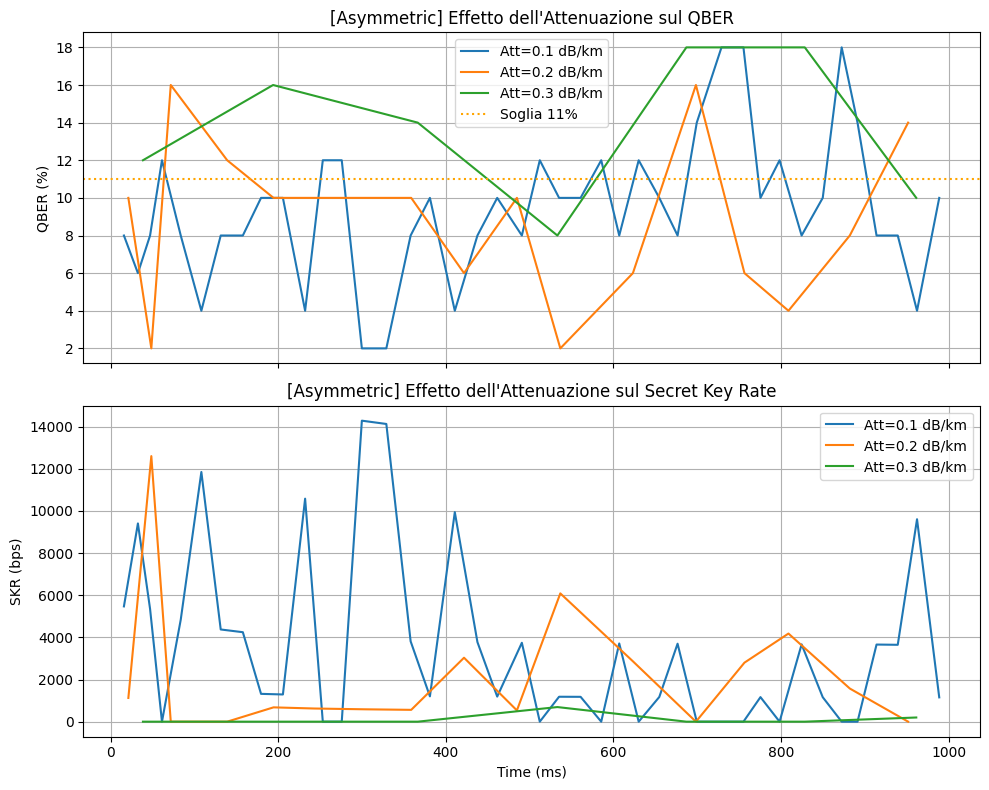

----------------------------------------


In [4]:
for topo_name, results_att in all_results_att.items():
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
    
    for att, df in results_att.items():
        time_ms = df['time_stamp'] / 1e6
        ax1.plot(time_ms, df['qber']*100, label=f"Att={att} dB/km")
        ax2.plot(time_ms, df['skr_bps'], label=f"Att={att} dB/km")

    ax1.set_ylabel("QBER (%)")
    ax1.set_title(f"[{topo_name}] Effetto dell'Attenuazione sul QBER")
    ax1.axhline(y=11, color='orange', linestyle=':', label="Soglia 11%")
    ax1.legend()
    ax1.grid(True)

    ax2.set_ylabel("SKR (bps)")
    ax2.set_xlabel("Time (ms)")
    ax2.set_title(f"[{topo_name}] Effetto dell'Attenuazione sul Secret Key Rate")
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plot_path = os.path.join('results', 'plots', f'exp1_attenuation_{topo_name.lower()}.png')
    plt.savefig(plot_path, dpi=300)
    print(f"Plot salvato in: {plot_path}")
    plt.show()
    print("-" * 40)

## 2. Test: Decoerenza delle Memorie Quantistiche (T1)
Aspettativa: Abbassando T1, gli stati quantistici memorizzati perdono fedeltà più in fretta. Il QBER schizza oltre la soglia, azzerando l'SKR.

In [ ]:
t1_values = [1e9, 1e8, 1e7] # da 1 secondo a 10ms
all_results_t1 = {}

for topo_name, topo_file, sim_script, def_csv in topologies:
    print(f"\n--- Avvio test Decoerenza T1 per topologia: {topo_name} ---")
    all_results_t1[topo_name] = {}
    for t1 in t1_values:
        custom_csv = f'results/{topo_name.lower()}_t1_{int(t1)}.csv'
        df = run_experiment(
            topology_file=topo_file,
            config_updates={'memory_T1': t1},
            simulation_script=sim_script,
            default_csv=def_csv,
            custom_csv_name=custom_csv
        )
        all_results_t1[topo_name][t1] = df

print("\nTutte le simulazioni di decoerenza T1 completate!")

Plot salvato in: results/plots/exp2_t1_decoherence_asymmetric.png


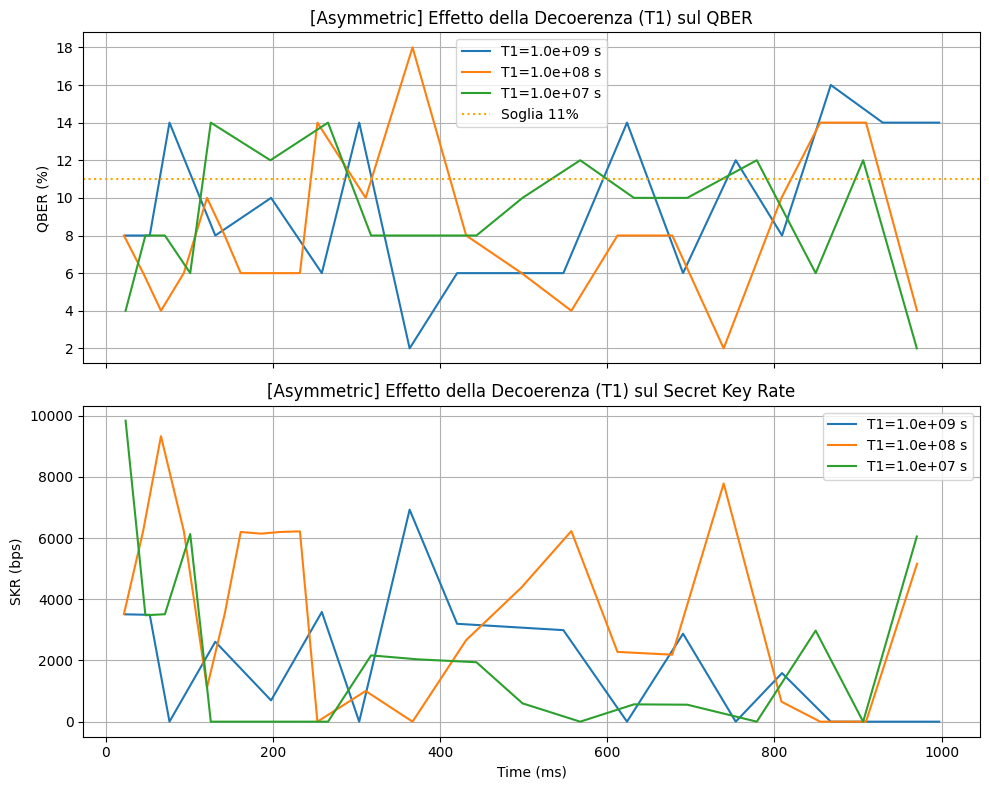

----------------------------------------


In [6]:
for topo_name, results_t1 in all_results_t1.items():
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
    
    for t1, df in results_t1.items():
        time_ms = df['time_stamp'] / 1e6
        ax1.plot(time_ms, df['qber']*100, label=f"T1={t1:.1e} s")
        ax2.plot(time_ms, df['skr_bps'], label=f"T1={t1:.1e} s")

    ax1.set_ylabel("QBER (%)")
    ax1.set_title(f"[{topo_name}] Effetto della Decoerenza (T1) sul QBER")
    ax1.axhline(y=11, color='orange', linestyle=':', label="Soglia 11%")
    ax1.legend()
    ax1.grid(True)

    ax2.set_ylabel("SKR (bps)")
    ax2.set_xlabel("Time (ms)")
    ax2.set_title(f"[{topo_name}] Effetto della Decoerenza (T1) sul Secret Key Rate")
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plot_path = os.path.join('results', 'plots', f'exp2_t1_decoherence_{topo_name.lower()}.png')
    plt.savefig(plot_path, dpi=300)
    print(f"Plot salvato in: {plot_path}")
    plt.show()
    print("-" * 40)